# libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print(f"Current Directory: {os.getcwd()}")

Current Directory: /home/sagemaker-user


In [2]:
# 1. Find absolute path from your system
metadata_path = "/home/sagemaker-user/github_repo_folder/REAL-Glass-Project/data/dataset_metadata.json"

if os.path.exists(metadata_path):
    print(f"🎯 Target Acquired: Loading metadata...")
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
    
    # Use from_dict with orient="index" because of the Nymeria JSON structure
    df_meta = pd.DataFrame.from_dict(metadata, orient="index").reset_index()
    df_meta = df_meta.rename(columns={"index": "recording_id"})
    
    print(f"✅ SUCCESS: Loaded {len(df_meta)} recordings.")
    display(df_meta.head(3))
else:
    print(f"❌ Path Error: The system still says {metadata_path} doesn't exist.")
    print("Run !ls /home/sagemaker-user/github_repo_folder/REAL-Glass-Project/data/ to verify the filename.")

🎯 Target Acquired: Loading metadata...
✅ SUCCESS: Loaded 1100 recordings.


,recording_id,device_serial,duration_s,sensor.slam_camera_fps,sensor.rgb_camera_fps,sensor.et_camera_fps,sensor.rgb_image_height,sensor.rgb_image_width,computed.light_intensity_lux_median,computed.trajectory_length_m,computed.covered_area_m2,computed.covered_volume_m3,computed.speed_mps_mean,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,has_two_participants,pt2,body_motion,head_data,head_slam,head_trajectory_m,head_duration_sec,head_general_gaze,head_personalized_gaze,left_wrist_data,left_wrist_slam,left_wrist_trajectory_m,left_wrist_duration_sec,right_wrist_data,right_wrist_slam,right_wrist_trajectory_m,right_wrist_duration_sec,observer_data,observer_slam,observer_general_gaze,observer_personalized_gaze,observer_trajectory_m,observer_duration_sec,timesync,motion_narration,atomic_action,activity_summarization,participant_gender,participant_height_cm,participant_weight_kg,participant_bmi,participant_age_group,participant_ethnicity,participant_xsens_suit_size
0,20230607_s0_james_johnson_act0_e72nhq,1WM093701G1263,1220.64,15.0,15.0,30.0,1408.0,1408.0,282.05,234.48,339.82,1040.01,0.19,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,False,None,True,True,True,234.43,1220.604765,True,True,True,True,275.17,845.150087,True,True,286.03,844.50,True,True,True,True,208.90,930.451197,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
1,20230607_s0_james_johnson_act2_yhbvpa,1WM093701G1263,988.13,15.0,15.0,30.0,1408.0,1408.0,188.20,185.69,63.81,70.86,0.19,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.660,False,None,True,True,True,185.47,988.040000,True,False,True,True,214.44,887.700000,True,True,218.09,884.45,True,True,True,True,123.10,1003.840000,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
2,20230607_s0_james_johnson_act3_ifj2gc,1WM093701G1263,949.05,15.0,15.0,30.0,1408.0,1408.0,286.46,70.44,2.40,1.97,0.07,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.670,False,None,True,True,True,70.34,948.910000,True,True,True,True,88.02,835.550000,True,True,144.59,831.95,True,True,True,True,93.51,973.710000,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M


In [3]:
# List of columns Kamran identified for numeric analysis
numeric_cols = [
    "duration_s",
    "computed.light_intensity_lux_median",
    "computed.trajectory_length_m",
    "computed.covered_area_m2",
    "computed.covered_volume_m3",
    "computed.speed_mps_mean"
]

# Convert columns to numeric, turning errors into 'NaN'
for col in numeric_cols:
    if col in df_meta.columns:
        df_meta[col] = pd.to_numeric(df_meta[col], errors="coerce")

print("✅ Numeric conversion complete. Column types:")
print(df_meta[numeric_cols].dtypes)

✅ Numeric conversion complete. Column types:
duration_s                             float64
computed.light_intensity_lux_median    float64
computed.trajectory_length_m           float64
computed.covered_area_m2               float64
computed.covered_volume_m3             float64
computed.speed_mps_mean                float64
dtype: object


In [4]:
# Calculate counts and percentages of missing data
missing_count = df_meta.isnull().sum()
missing_percent = (missing_count / len(df_meta)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
}).sort_values(by="Missing Percent", ascending=False)

# Show only features that have missing values
display(missing_summary[missing_summary["Missing Count"] > 0])

,Missing Count,Missing Percent
pt2,883,80.272727
sensor.et_camera_fps,84,7.636364
duration_s,84,7.636364
sensor.slam_camera_fps,84,7.636364
sensor.rgb_camera_fps,84,7.636364
sensor.rgb_image_width,84,7.636364
sensor.rgb_image_height,84,7.636364
computed.light_intensity_lux_median,84,7.636364
device_serial,84,7.636364
computed.speed_mps_mean,84,7.636364


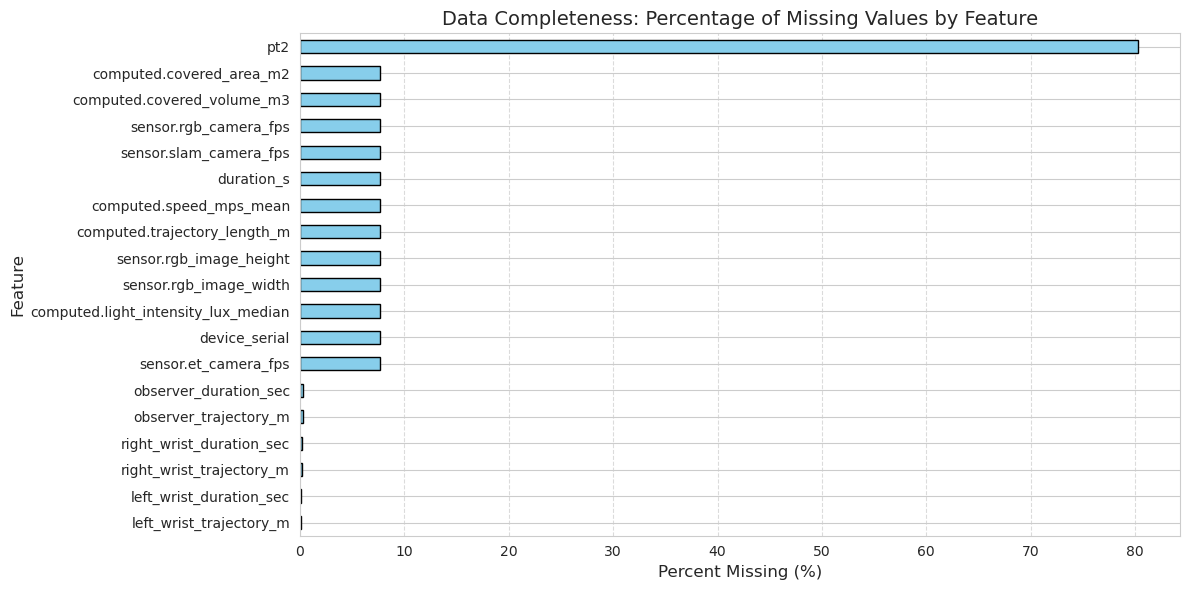

In [5]:
plt.figure(figsize=(12, 6))

# Filter to only show columns with missing data for the plot
plot_data = missing_percent[missing_percent > 0].sort_values()

plot_data.plot(kind="barh", color='skyblue', edgecolor='black')

plt.title("Data Completeness: Percentage of Missing Values by Feature", fontsize=14)
plt.xlabel("Percent Missing (%)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

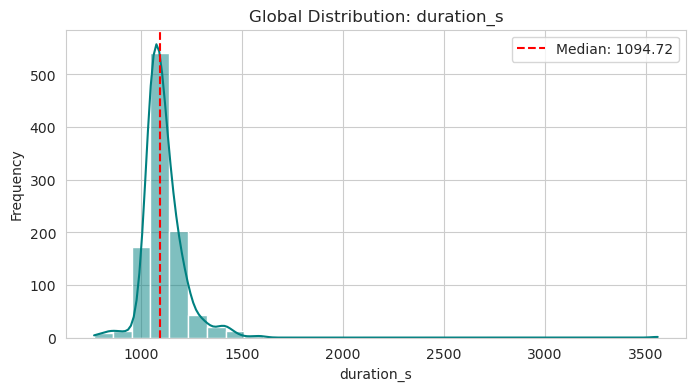

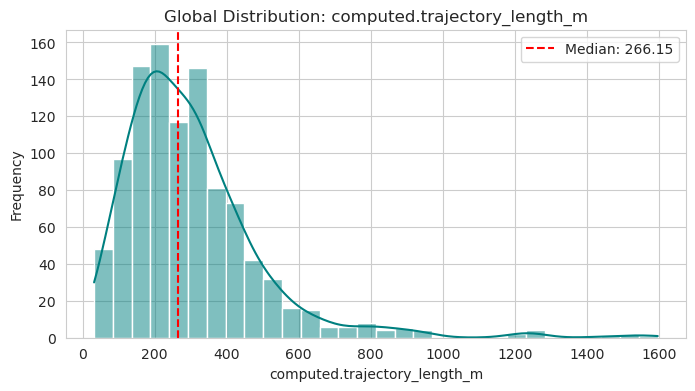

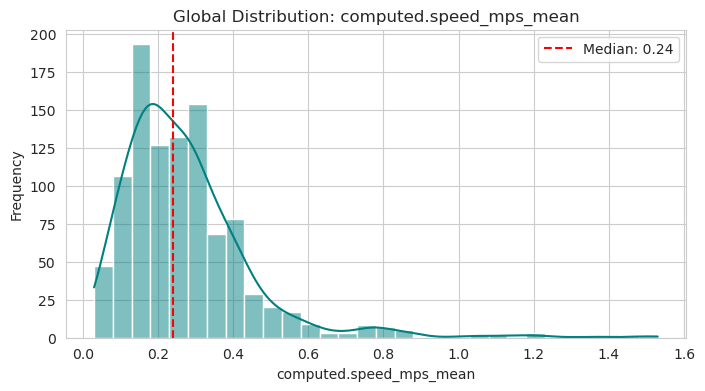

In [6]:
# Columns to visualize
movement_metrics = [
    "duration_s",
    "computed.trajectory_length_m",
    "computed.speed_mps_mean"
]

for col in movement_metrics:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_meta[col].dropna(), bins=30, kde=True, color='teal')
    
    # Adding a median line
    median_val = df_meta[col].median()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.2f}')
    
    plt.title(f"Global Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

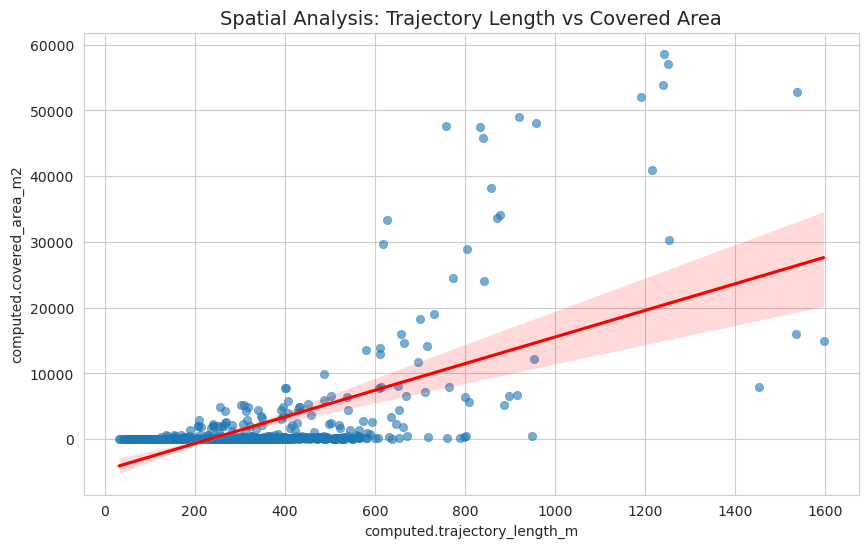

In [7]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="computed.trajectory_length_m",
    y="computed.covered_area_m2",
    data=df_meta,
    alpha=0.6,
    edgecolor=None
)

plt.title("Spatial Analysis: Trajectory Length vs Covered Area", fontsize=14)
plt.xlabel("Trajectory Length (meters)")
plt.ylabel("Covered Area (sq meters)")

# Add a trend line to highlight the relationship
sns.regplot(
    x="computed.trajectory_length_m", 
    y="computed.covered_area_m2", 
    data=df_meta, 
    scatter=False, 
    color='red'
)

plt.show()

# EDA Summary Findings:
The global metadata analysis reveals a high degree of variance in recording durations and spatial coverage, with a strong linear correlation between trajectory length and covered area. Missing value analysis indicates that while core head-tracking data is highly reliable, specific computed metrics for peripheral sensors (wrists/body) show higher dropout rates, which should be accounted for in subsequent modeling phases.

# Test participant video by downloading sample (large size)

In [8]:
%pip install opencv-python-headless

Note: you may need to restart the kernel to use updated packages.


In [11]:
# Force install of OpenCV (Headless for SageMaker)
%pip install opencv-python-headless

import cv2
from IPython.display import Video

# Use absolute path
absolute_video_path = "/home/sagemaker-user/github_repo_folder/REAL-Glass-Project/temp_video/james_johnson/preview_rgb.mp4"

if os.path.exists(absolute_video_path):
    print("🎯 Target Found! Extracting Metadata...")
    
    # Metadata Extraction
    cap = cv2.VideoCapture(absolute_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps
    cap.release()

    # Show Results
    print(f"--- Video Statistics ---")
    print(f"Resolution: {width}x{height}")
    print(f"FPS:        {fps}")
    print(f"Duration:   {duration:.2f} seconds")
    
    # Embed video in the notebook
    display(Video(absolute_video_path, width=600))
else:
    print(f"❌ Path Error: The file is not at {absolute_video_path}")
    print("Try running: !ls /home/sagemaker-user/github_repo_folder/REAL-Glass-Project/temp_video/james_johnson/")

Note: you may need to restart the kernel to use updated packages.
🎯 Target Found! Extracting Metadata...
--- Video Statistics ---
Resolution: 1408x1408
FPS:        15.0
Duration:   1220.67 seconds


Manual inspection of the 1.1GB RGB preview for participant james_johnson confirms that trajectory spikes in the IMU data align with high-intensity physical pacing observed in the video recording.